# IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Loading

In [3]:
df = pd.read_csv("loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


# DATA EXPLORATION

### COLUMNS NAME

In [4]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

### FIRST FIVE ROWS

In [5]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### LAST FIVE ROWS

In [6]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


### INFORMATION OF DATASET

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


### SHAPE OF DATASET(ROWS,COLUMNS)

In [8]:
df.shape

(4269, 13)

### STATISTICAL INFORMATION

In [9]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


### FINDING UNIQUE VALUES

In [10]:
df["loan_id"].unique()

array([   1,    2,    3, ..., 4267, 4268, 4269], shape=(4269,))

In [11]:
df[" no_of_dependents"].unique()

array([2, 0, 3, 5, 4, 1])

In [12]:
df[" education"].unique()

<ArrowStringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

In [13]:
df[" self_employed"].unique()

<ArrowStringArray>
[' No', ' Yes']
Length: 2, dtype: str

In [14]:
df[" income_annum"].unique()

array([9600000, 4100000, 9100000, 8200000, 9800000, 4800000, 8700000,
       5700000,  800000, 1100000, 2900000, 6700000, 5000000, 1900000,
       4700000,  500000, 2700000, 6300000, 5800000, 6500000, 4900000,
       3100000, 2400000, 7000000, 9000000, 8400000, 1700000, 1600000,
       8000000, 3600000, 1500000, 7800000, 1400000, 4200000, 5500000,
       9500000, 7300000, 3800000, 5100000, 4300000, 9300000, 7400000,
       8500000, 8800000, 3300000, 3900000, 8300000, 5600000, 5300000,
       2600000,  700000, 3500000, 9900000, 3000000, 6800000, 2000000,
       1000000,  300000, 6600000, 9400000, 4400000,  400000, 6200000,
       9700000, 7100000,  600000, 7200000,  900000,  200000, 1800000,
       4600000, 2200000, 2500000, 8600000, 4000000, 5200000, 8900000,
       1300000, 4500000, 8100000, 9200000, 2800000, 7500000, 6400000,
       6900000, 7700000, 3200000, 7900000, 5900000, 3400000, 2100000,
       3700000, 5400000, 2300000, 7600000, 6000000, 6100000, 1200000])

In [15]:
df[" loan_amount"].unique()

array([29900000, 12200000, 29700000, 30700000, 24200000, 13500000,
       33000000, 15000000,  2200000,  4300000, 11200000, 22700000,
       11600000, 31500000,  7400000, 10700000,  1600000,  9400000,
       10300000, 14600000, 19400000, 14000000, 25700000,  1400000,
        9800000,  9500000, 28100000,  5600000, 24000000, 25300000,
       12000000, 22000000, 11900000,  3400000,  6200000, 27200000,
        7700000,  5100000, 18100000, 24900000,  2300000, 13400000,
       27800000, 19100000, 20500000, 25400000, 24700000,  7600000,
       23000000, 19700000, 24500000, 10600000, 30500000, 18400000,
       18200000, 18900000, 28900000,  7500000, 12300000, 29100000,
       10100000, 12400000,  5000000,  1500000, 18600000, 18300000,
       16700000,  8400000,  6500000, 14800000, 33500000, 29400000,
        8900000, 31200000, 21200000,  8600000,  8200000,  3800000,
       28300000,  8000000, 37600000, 21100000, 20700000,  6400000,
        2000000,  1100000, 25000000, 10800000,   900000, 12900

In [16]:
df[" loan_term"].unique()

array([12,  8, 20, 10,  4,  2, 18, 16, 14,  6])

In [17]:
df[" cibil_score"].unique()

array([778, 417, 506, 467, 382, 319, 678, 782, 388, 547, 538, 311, 679,
       469, 794, 663, 780, 736, 652, 315, 530, 551, 324, 514, 696, 662,
       336, 850, 313, 363, 436, 830, 612, 691, 636, 348, 352, 712, 822,
       540, 342, 787, 331, 677, 634, 502, 435, 689, 657, 590, 818, 431,
       841, 421, 797, 478, 669, 365, 586, 784, 364, 715, 693, 777, 312,
       340, 386, 418, 735, 494, 671, 697, 801, 576, 639, 470, 826, 613,
       713, 439, 387, 402, 837, 641, 489, 844, 452, 366, 300, 861, 562,
       463, 702, 618, 633, 764, 591, 719, 317, 302, 879, 437, 456, 647,
       379, 717, 545, 570, 865, 821, 859, 395, 429, 565, 357, 465, 479,
       425, 786, 564, 501, 727, 894, 829, 802, 543, 772, 572, 709, 481,
       306, 415, 548, 701, 890, 704, 318, 761, 524, 681, 737, 638, 656,
       341, 371, 886, 748, 376, 873, 309, 869, 534, 566, 742, 824, 575,
       766, 888, 622, 458, 327, 682, 583, 816, 455, 355, 389, 870, 827,
       768, 707, 665, 420, 471, 819, 809, 744, 484, 673, 695, 47

In [18]:
df[" residential_assets_value"].unique()

array([ 2400000,  2700000,  7100000, 18200000, 12400000,  6800000,
       22500000, 13200000,  1300000,  3200000,  8100000, 15300000,
        6400000, 10800000,  1900000,  5700000,  2900000,  1000000,
       10300000,  9500000,  3800000, 13100000,   900000,  7900000,
       11500000,  4500000,  2300000, 21800000, 20200000,  3600000,
         700000,  9700000,  3400000,  7000000,   100000,  8600000,
       22300000,   200000,  2200000, 13000000,  5400000,   800000,
         500000,  8700000, 15400000,  7400000,  1200000,  2100000,
       19300000, 18500000,  -100000, 23800000,  4700000, 24400000,
        1600000,  7600000,  6100000,  5500000,  4000000, 18400000,
        3900000,  6500000,   600000, 14300000, 11600000, 17600000,
       25500000,  9400000,  5300000, 17100000, 20400000,  5100000,
       24100000, 19200000,  9100000, 14700000, 25900000,   300000,
       11400000,  7800000, 19600000,  5600000,  7300000, 19500000,
       16100000,  1500000, 12700000, 26800000, 12200000,   400

In [19]:
df[" commercial_assets_value"].unique()

array([17600000,  2200000,  4500000,  3300000,  8200000,  8300000,
       14800000,  5700000,   800000,  1400000,  4700000,  5800000,
        9600000, 16600000,  1200000,  3900000,   100000,  2800000,
              0,  3500000,  1600000, 11300000,  1700000,   600000,
        8700000,  3100000, 10600000,  4200000, 11900000, 12400000,
        5200000,  7400000,   200000,   700000,   300000,  1300000,
       11200000, 12100000,  1500000,  6300000,  6900000,  9100000,
        8600000, 10500000,  1800000,  9300000,  5600000, 10300000,
        4900000, 16300000,  1900000,  6100000,  9700000, 11700000,
        9400000,  3800000,  2500000,  7800000,  8900000,   500000,
       11400000, 13600000,  2600000,  4300000,  3200000,  1100000,
         400000,  4800000,  8500000, 15200000,  3600000, 16500000,
        2700000,  7600000,  6000000, 12200000,  2000000,  1000000,
        6200000,  8000000,  5900000,  4100000,  6500000, 10000000,
       16700000,   900000,  2100000,  9500000,  5500000,  4400

In [20]:
df[" luxury_assets_value"].unique()

array([22700000,  8800000, 33300000, 23300000, 29400000, 13700000,
       29200000, 11800000,  2800000,  3300000,  9500000, 20400000,
       14600000, 20900000,  5900000, 16400000,  1300000,  6700000,
        6200000, 23500000, 18000000, 22200000, 19500000,  1100000,
       10000000,  6600000, 25300000,  5400000, 27500000, 33700000,
       25500000, 21700000,  2200000, 19900000, 19000000,  6000000,
        5300000, 16700000,  5600000, 31000000,  3900000,  1800000,
       16200000, 21400000,  8700000, 17700000, 18500000, 37700000,
       20500000, 21800000,  9300000, 31900000, 19400000, 16300000,
       34600000, 17500000, 18600000, 25900000, 26500000, 27400000,
       10500000, 13100000, 14900000, 24100000,  4900000,  1900000,
       11900000, 21500000, 12600000,  4800000, 12900000, 35400000,
       25200000,  2400000, 12300000, 26600000, 10300000, 11000000,
        3800000, 27900000, 23400000, 12500000, 22400000,  3200000,
         700000, 18200000, 23200000, 36400000, 13800000,  1200

In [21]:
df[" bank_asset_value"].unique()

array([ 8000000,  3300000, 12800000,  7900000,  5000000,  5100000,
        4300000,  6000000,   600000,  1600000,  3100000,  6400000,
        1900000,  4400000,   700000,  5900000,  6100000,  5400000,
        8500000,   300000,  2600000,  7200000,  2500000,  9700000,
        9300000,  1000000,  5800000,   900000,  1400000,  7100000,
        2900000,  9000000,  5200000,   800000, 10900000,  4900000,
        6500000,  8200000, 11700000, 10500000, 11300000,  3400000,
        6200000,  8700000,  4100000,  4800000, 11400000,  4700000,
        2800000, 11900000,  5500000,  2400000,  4200000,  7600000,
        5600000,  2000000,  1100000,  6300000, 11100000,  8600000,
        6800000,  3600000, 10200000, 12700000,  2100000,  1300000,
         400000,  7000000,  7300000,   100000,   200000, 11600000,
        1800000,  9800000,  8100000,  7500000, 13400000,  9600000,
        3800000,  8400000,  3200000,  1200000,  4600000,  8300000,
        4500000,  3500000,  2300000,  7400000,  1700000,  9500

In [22]:
df[" loan_status"].unique()

<ArrowStringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str

# DATA PREPROCESSING

### FINDING MISSING VALUES OF EACH COLUMNS

In [23]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

### FINDING DUPLICATE VALUES

In [24]:
df.duplicated().sum()

np.int64(0)

### REMOVING SPACES

In [25]:
df.columns=df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

In [26]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

# EDA ANALYSIS

### BOX PLOT

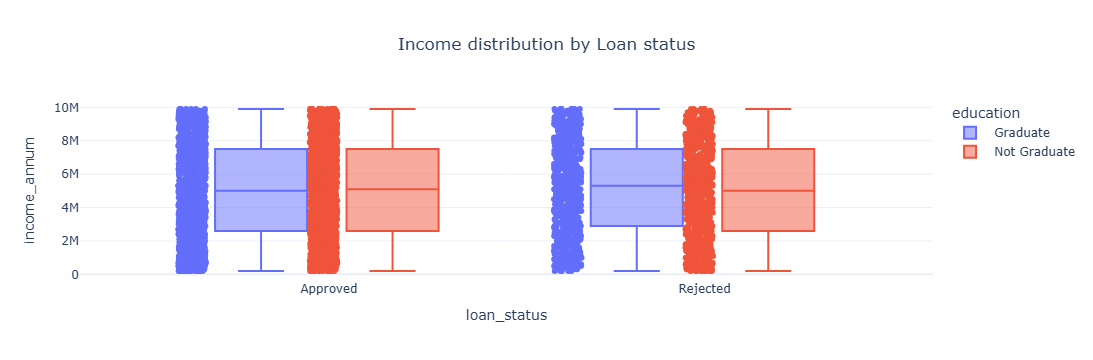

In [27]:
fig = px.box(df, x="loan_status", y="income_annum",color="education", points="all",title="Income distribution by Loan status")
fig.update_layout( title_x=0.5,template="plotly_white")
fig.show()

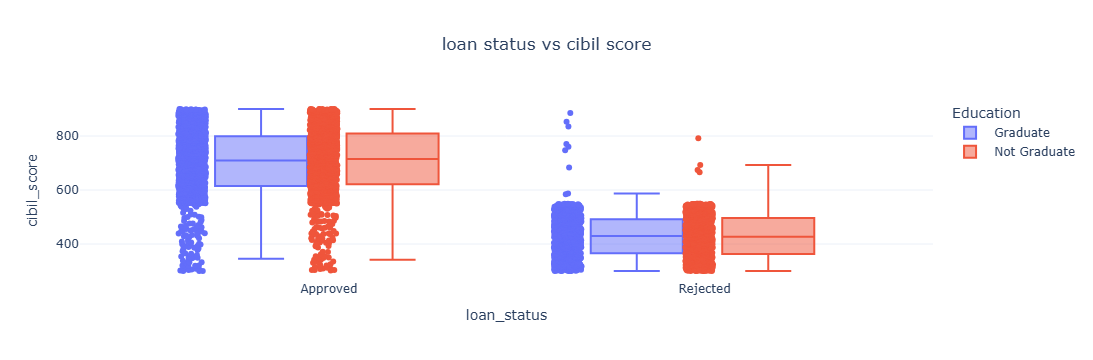

In [44]:
fig = px.box(df, x="loan_status", y="cibil_score",color="education", points="all", title="loan status vs cibil score")
fig.update_layout( title_x=0.5,template="plotly_white",legend_title="Education")
fig.show()

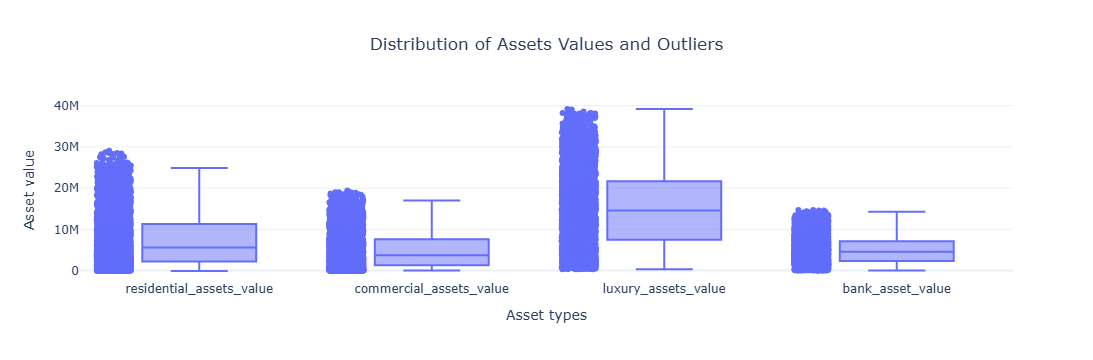

In [29]:
fig = px.box(df, y=["residential_assets_value","commercial_assets_value","luxury_assets_value","bank_asset_value"],points="all", title="Distribution of Assets Values and Outliers")
fig.update_layout( title_x=0.5,template="plotly_white",xaxis_title="Asset types",yaxis_title="Asset value")
fig.show()

### HISTOGRAM GRAPHS

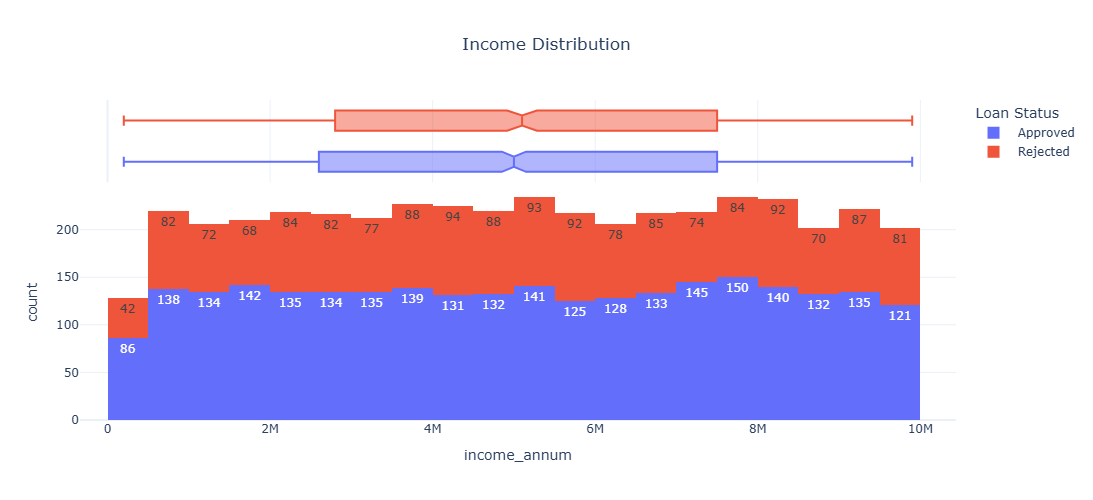

In [39]:
fig = px.histogram(df, x="income_annum", color="loan_status", text_auto=True,marginal="box", nbins=20, title="Income Distribution")
fig.update_layout(title_x=0.5,template="plotly_white",width=1000, height=500,legend_title="Loan Status")
fig.show()

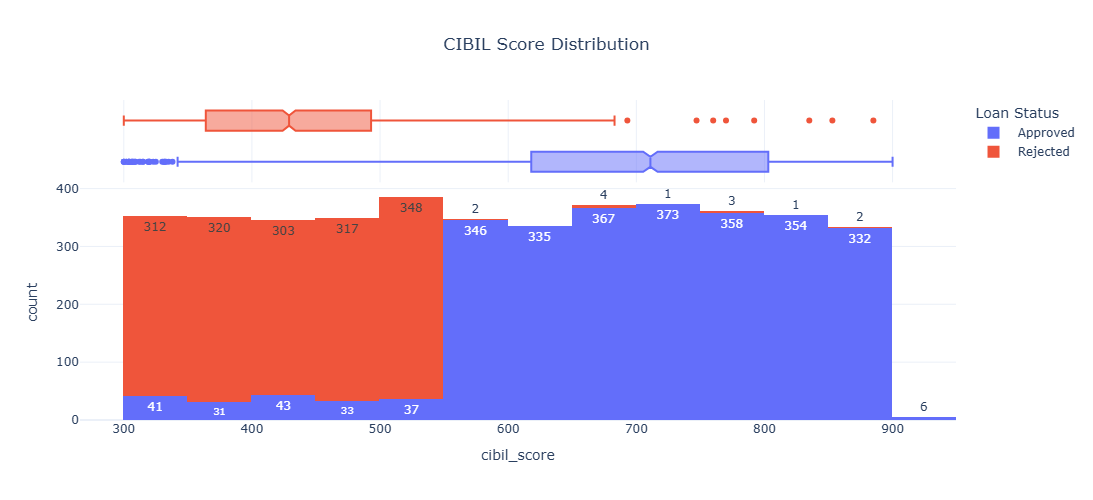

In [41]:
fig = px.histogram(df, x="cibil_score", color="loan_status", marginal="box",text_auto=True,nbins=30, title="CIBIL Score Distribution")
fig.update_layout(title_x=0.5,template="plotly_white",width=1000, height=500,legend_title="Loan Status")
fig.show()

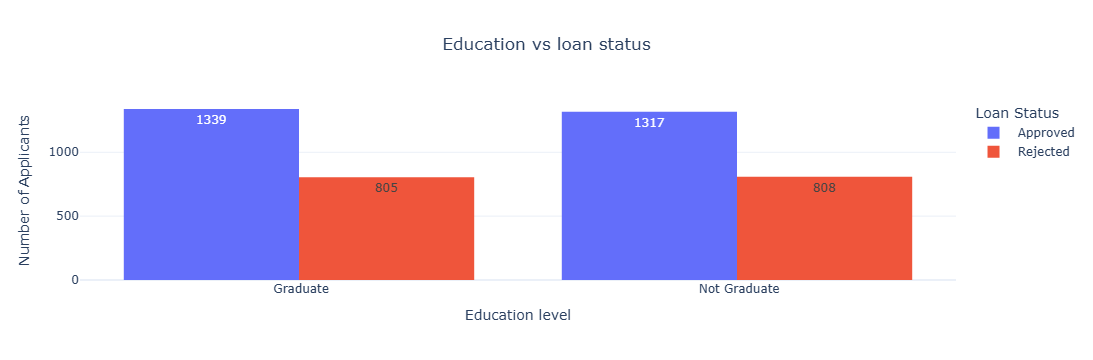

In [32]:
fig = px.histogram(df, x="education", color="loan_status", barmode="group",text_auto=True, title="Education vs loan status")
fig.update_layout(title_x=0.5,template="plotly_white",xaxis_title="Education level",yaxis_title="Number of Applicants",legend_title="Loan Status")
fig.show()

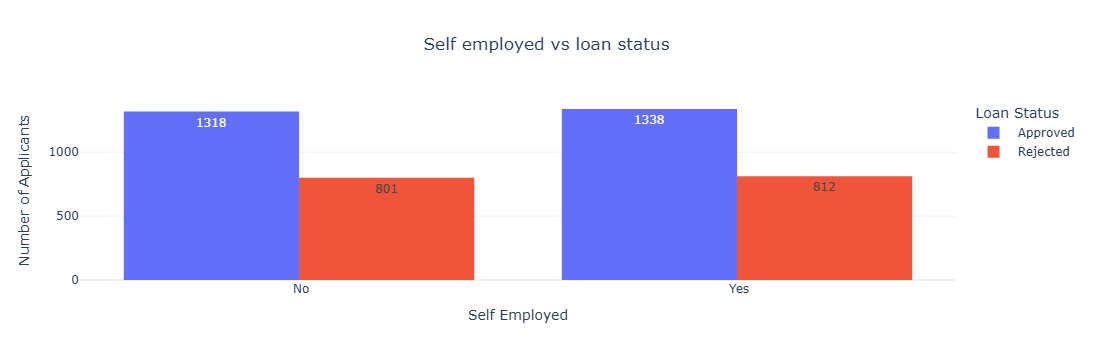

In [33]:
fig = px.histogram(df, x="self_employed", color="loan_status", barmode="group",text_auto=True, title="Self employed vs loan status")
fig.update_layout(title_x=0.5,template="plotly_white",xaxis_title="Self Employed",yaxis_title="Number of Applicants",legend_title="Loan Status")
fig.show()

### PARALLEL COORDINATES

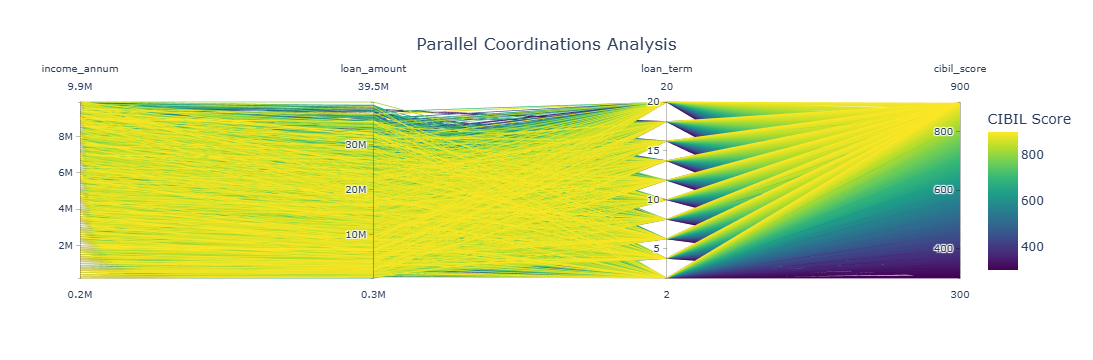

In [34]:
fig=px.parallel_coordinates(df,dimensions=["income_annum","loan_amount","loan_term","cibil_score"],color="cibil_score",color_continuous_scale=px.colors.sequential.Viridis,title="Parallel Coordinations Analysis")
fig.update_layout(title_x=0.5,template="plotly_white",coloraxis_colorbar_title="CIBIL Score")
fig.show()

### SUNBURST GRAPH

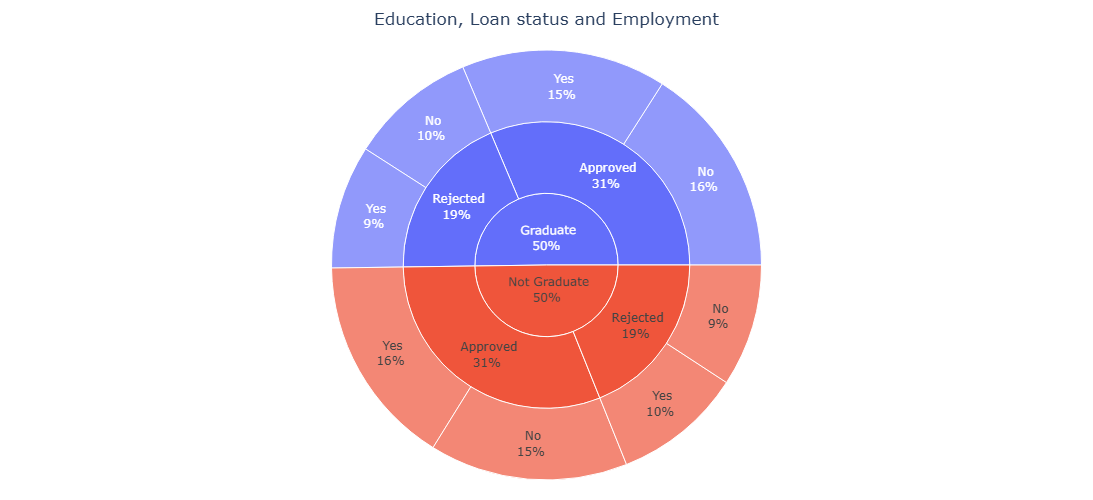

In [38]:
fig=px.sunburst(df, path=["education","loan_status","self_employed"],title="Education, Loan status and Employment")
fig.update_traces(textinfo="label+percent entry")
fig.update_layout(title_x=0.5, template="plotly_white", width=700, height=500,margin=dict(t=50,l=20,r=20,b=20))
fig.show()

### TREEMAP

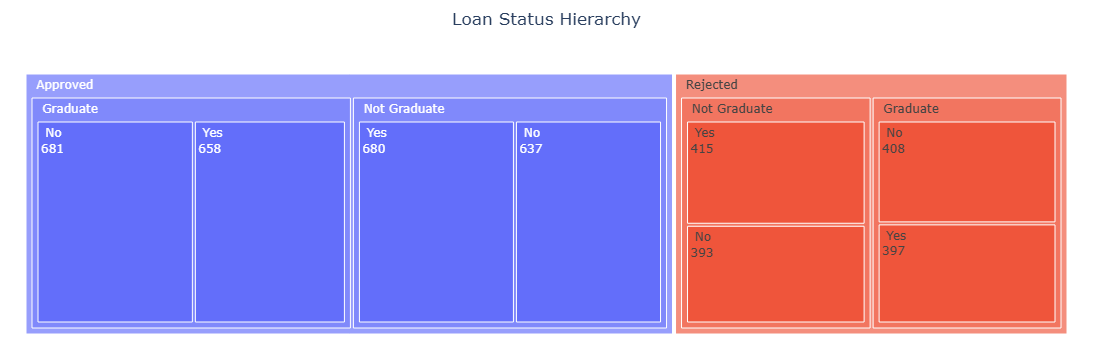

In [36]:
fig=px.treemap(df,path=["loan_status","education","self_employed"],title="Loan Status Hierarchy")
fig.update_traces(textinfo="label+value")
fig.update_layout(title_x=0.5,template="plotly_white",margin=dict(t=50,l=20,r=20,b=20))
fig.show()

### PIE GRAPH

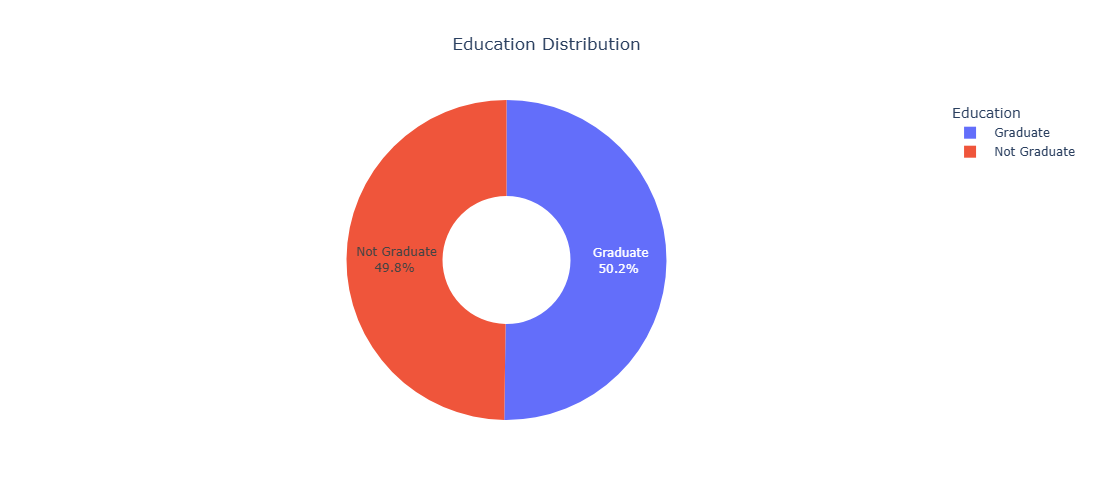

In [37]:
fig = px.pie(df, names="education", title="Education Distribution",hole=0.4)
fig.update_traces(textinfo="percent+label")
fig.update_layout(title_x=0.5, template="plotly_white", width=700, height=500,legend_title="Education")
fig.show()

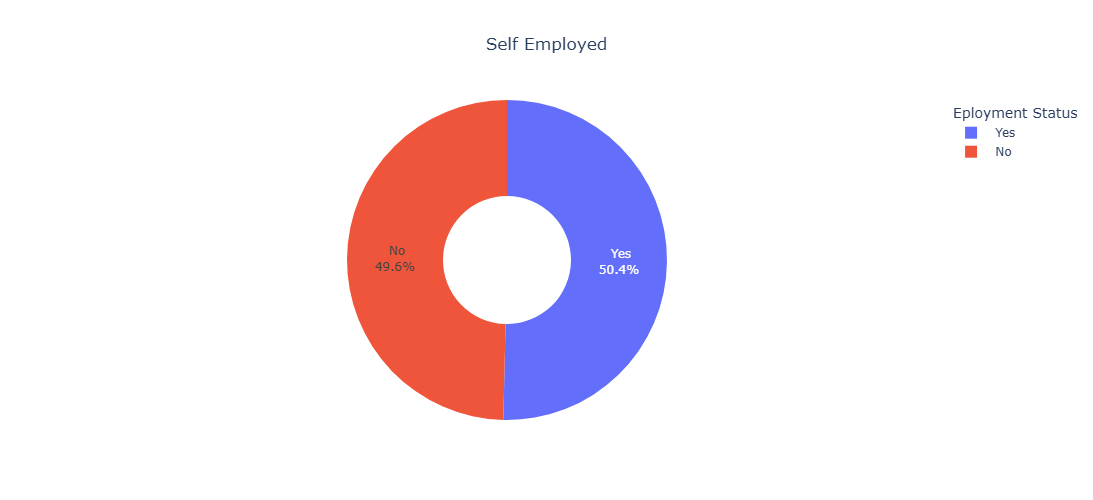

In [37]:
fig = px.pie(df, names="self_employed", title="Self Employed",hole=0.4)
fig.update_traces(textinfo="percent+label")
fig.update_layout(title_x=0.5, template="plotly_white", width=700, height=500,legend_title="Eployment Status")
fig.show()

### SCATTER GRAPH

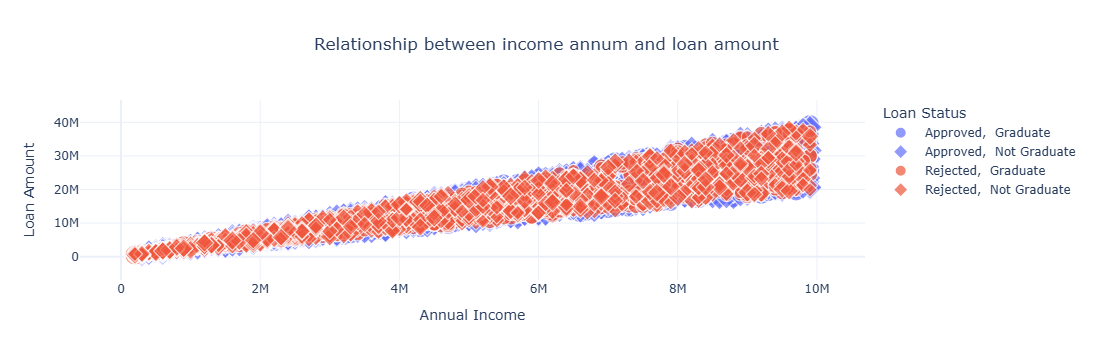

In [45]:
fig = px.scatter(df, x="income_annum", y="loan_amount", color="loan_status", size="cibil_score", symbol="education", title="Relationship between income annum and loan amount")
fig.update_layout( title_x=0.5,template="plotly_white",xaxis_title="Annual Income",yaxis_title="Loan Amount",legend_title="Loan Status")
fig.update_traces(marker=dict(line=dict(width=1)))
fig.show()

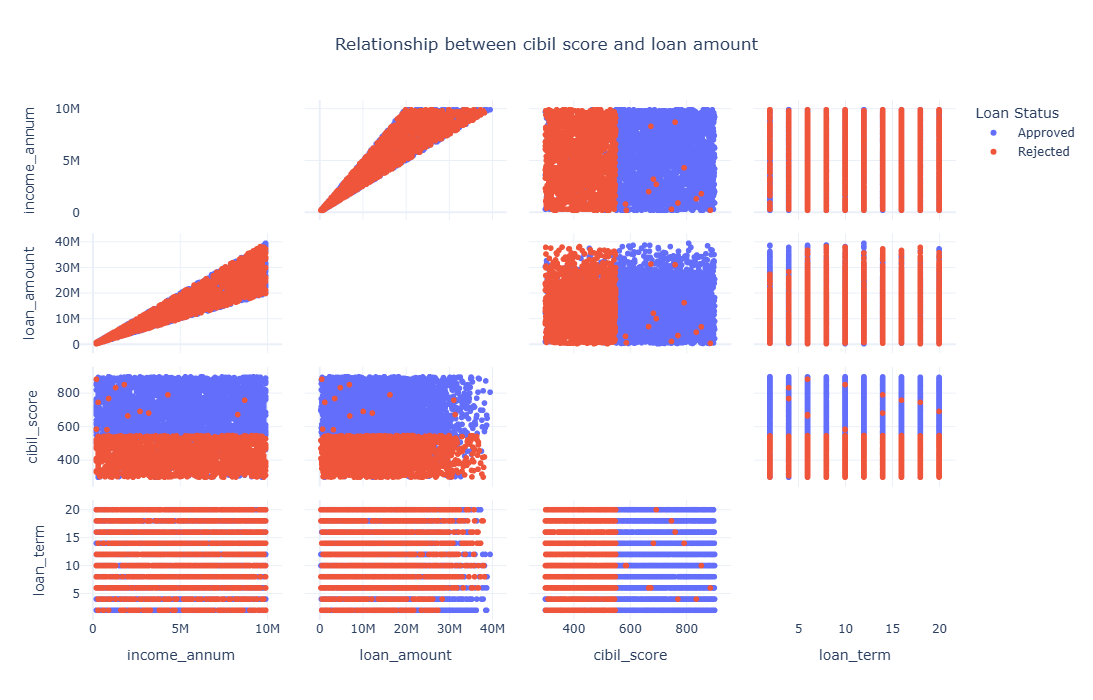

In [39]:
fig = px.scatter_matrix(df, dimensions=["income_annum", "loan_amount", "cibil_score", "loan_term"], color="loan_status", title="Relationship between cibil score and loan amount")
fig.update_traces(diagonal_visible=False)
fig.update_layout( title_x=0.5,template="plotly_white",legend_title="Loan Status",width=1000, height=700)
fig.show()

### HEATMAP GRAPH

In [40]:
corr = df.select_dtypes(include="number").corr()
corr

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_id,1.000000,0.005326,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765
no_of_dependents,0.005326,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.012592,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,0.008170,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122
loan_term,0.009809,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,0.016323,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.020936,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,0.018595,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,-0.000862,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.010765,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000


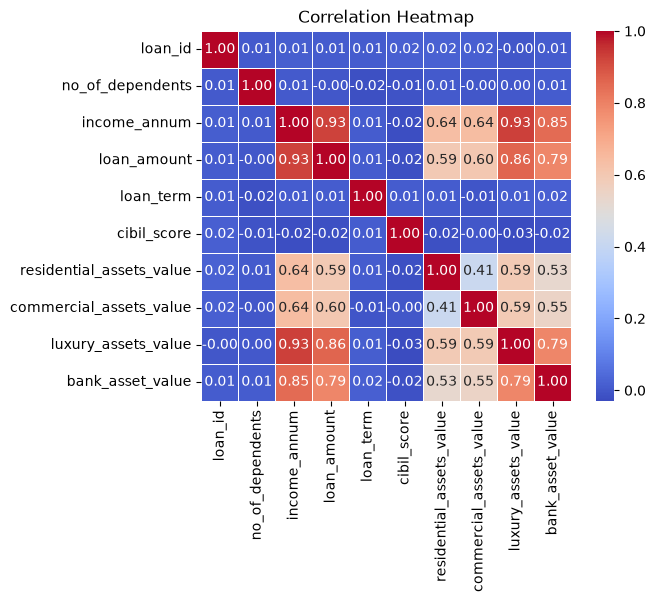

In [41]:
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f",linewidths=0.5,square=True)
plt.title("Correlation Heatmap")
plt.show()

### VOILIN GRAPH

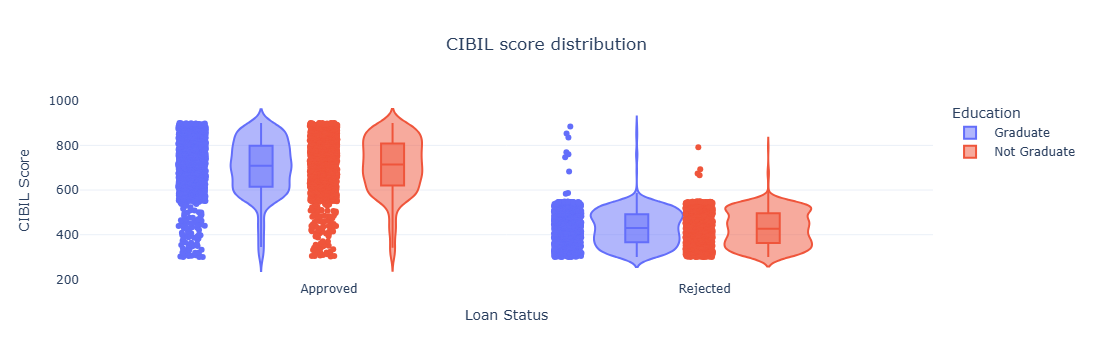

In [42]:
fig = px.violin(df,x="loan_status", y="cibil_score",color="education",box=True,points="all",title="CIBIL score distribution")
fig.update_layout(title_x=0.5,template="plotly_white",xaxis_title="Loan Status",yaxis_title="CIBIL Score",legend_title="Education")
fig.show()